In [3]:
# =============================================================================
# JupedSim SQLite数据分析脚本 - 适配实际数据结构
# =============================================================================

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和图表样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

class JupedSimAnalyzer:
    """JupedSim轨迹数据分析器 - 适配实际数据结构"""
    
    def __init__(self, data_directory, table_name="trajectory_data"):
        """
        初始化分析器
        
        Parameters:
        data_directory: SQLite文件所在目录
        table_name: 数据表名称
        """
        self.data_directory = Path(data_directory)
        self.table_name = table_name
        self.runs_data = {}
        self.summary_stats = {}
        
        # 实际数据列映射
        self.column_mapping = {
            'frame': 'frame',           # 帧号
            'id': 'id',                # 行人ID
            'pos_x': 'pos_x',          # X坐标
            'pos_y': 'pos_y',          # Y坐标
            'ori_x': 'ori_x',          # 方向X分量
            'ori_y': 'ori_y',          # 方向Y分量
            'source_file': 'source_file', # 源文件
            'run_id': 'run_id'         # 运行ID
        }
        
    def load_single_sqlite(self, sqlite_path):
        """读取单个SQLite文件"""
        try:
            conn = sqlite3.connect(sqlite_path)
            
            # 首先检查表结构
            tables_query = "SELECT name FROM sqlite_master WHERE type='table'"
            tables = pd.read_sql_query(tables_query, conn)
            
            if self.table_name not in tables['name'].values:
                # 如果指定表不存在，使用第一个可用表
                available_table = tables['name'].iloc[0]
                print(f"表 '{self.table_name}' 不存在，使用 '{available_table}'")
                self.table_name = available_table
            
            # 读取数据
            df = pd.read_sql_query(f"SELECT * FROM {self.table_name}", conn)
            conn.close()
            
            return df
            
        except Exception as e:
            print(f"读取文件 {sqlite_path} 失败: {e}")
            return None
    
    def load_all_runs(self, pattern="*.sqlite"):
        """加载所有SQLite文件"""
        sqlite_files = list(self.data_directory.glob(pattern))
        
        if not sqlite_files:
            print(f"在 {self.data_directory} 中未找到匹配 {pattern} 的文件")
            return 0
            
        print(f"找到 {len(sqlite_files)} 个SQLite文件")
        
        for i, sqlite_file in enumerate(sorted(sqlite_files), 1):
            df = self.load_single_sqlite(sqlite_file)
            if df is not None:
                # 如果数据没有source_file和run_id列，添加它们
                if 'source_file' not in df.columns:
                    df['source_file'] = sqlite_file.stem
                if 'run_id' not in df.columns:
                    df['run_id'] = i
                
                self.runs_data[f"run_{i}"] = df
                print(f"✓ 成功加载运行 {i}: {sqlite_file.name} ({len(df)} 行数据)")
            else:
                print(f"✗ 加载运行 {i} 失败: {sqlite_file.name}")
                
        return len(self.runs_data)
    
    def get_data_overview(self):
        """获取数据概览"""
        if not self.runs_data:
            print("请先加载数据")
            return
            
        overview = {}
        sample_data = list(self.runs_data.values())[0]
        
        overview['总运行次数'] = len(self.runs_data)
        overview['数据列'] = list(sample_data.columns)
        overview['数据类型'] = dict(sample_data.dtypes)
        overview['样本数据行数'] = len(sample_data)
        
        # 检查关键列是否存在
        key_columns = ['id', 'frame', 'pos_x', 'pos_y']
        overview['关键列存在性'] = {col: col in sample_data.columns for col in key_columns}
        
        return overview
    
    def calculate_evacuation_metrics(self):
        """计算疏散关键指标"""
        all_metrics = {}
        
        for run_name, data in self.runs_data.items():
            metrics = {}
            
            # 基础统计
            metrics['total_agents'] = data['id'].nunique()
            metrics['total_frames'] = data['frame'].max()
            metrics['time_step'] = 0.1  # 假设时间步长为0.1秒
            metrics['total_time'] = metrics['total_frames'] * metrics['time_step']
            
            # 个体疏散时间分析
            agent_evacuation = data.groupby('id')['frame'].agg(['min', 'max', 'count'])
            agent_evacuation['duration_frames'] = agent_evacuation['max'] - agent_evacuation['min']
            agent_evacuation['duration_seconds'] = agent_evacuation['duration_frames'] * metrics['time_step']
            
            metrics['avg_evacuation_time'] = agent_evacuation['duration_seconds'].mean()
            metrics['max_evacuation_time'] = agent_evacuation['duration_seconds'].max()
            metrics['min_evacuation_time'] = agent_evacuation['duration_seconds'].min()
            metrics['std_evacuation_time'] = agent_evacuation['duration_seconds'].std()
            
            # 阶段性疏散分析
            evacuation_timeline = data.groupby('frame')['id'].nunique().cumsum()
            total_agents = metrics['total_agents']
            
            for pct in [20, 40, 60, 80, 100]:
                target_agents = int(total_agents * pct / 100)
                if target_agents <= total_agents:
                    try:
                        evacuation_frame = evacuation_timeline[evacuation_timeline >= target_agents].index[0]
                        metrics[f'time_for_{pct}pct'] = evacuation_frame * metrics['time_step']
                    except IndexError:
                        metrics[f'time_for_{pct}pct'] = metrics['total_time']
            
            # 计算瞬时速度
            data_sorted = data.sort_values(['id', 'frame'])
            data_sorted['prev_x'] = data_sorted.groupby('id')['pos_x'].shift(1)
            data_sorted['prev_y'] = data_sorted.groupby('id')['pos_y'].shift(1)
            
            # 计算位移距离
            data_sorted['distance'] = np.sqrt(
                (data_sorted['pos_x'] - data_sorted['prev_x'])**2 + 
                (data_sorted['pos_y'] - data_sorted['prev_y'])**2
            )
            
            # 计算瞬时速度
            data_sorted['speed'] = data_sorted['distance'] / metrics['time_step']
            
            # 速度统计（排除异常值）
            speed_data = data_sorted[
                (data_sorted['speed'].notna()) & 
                (data_sorted['speed'] > 0) & 
                (data_sorted['speed'] < 10)  # 排除异常高速度
            ]
            
            if not speed_data.empty:
                metrics['avg_speed'] = speed_data['speed'].mean()
                metrics['max_speed'] = speed_data['speed'].max()
                metrics['speed_std'] = speed_data['speed'].std()
                metrics['median_speed'] = speed_data['speed'].median()
            else:
                metrics['avg_speed'] = 0
                metrics['max_speed'] = 0
                metrics['speed_std'] = 0
                metrics['median_speed'] = 0
            
            # 计算方向变化（如果有方向数据）
            if 'ori_x' in data.columns and 'ori_y' in data.columns:
                # 计算方向角度
                data_sorted['orientation_angle'] = np.arctan2(data_sorted['ori_y'], data_sorted['ori_x'])
                data_sorted['prev_orientation'] = data_sorted.groupby('id')['orientation_angle'].shift(1)
                
                # 计算方向变化
                data_sorted['direction_change'] = np.abs(data_sorted['orientation_angle'] - data_sorted['prev_orientation'])
                # 处理角度跨越问题
                data_sorted['direction_change'] = np.minimum(
                    data_sorted['direction_change'], 
                    2*np.pi - data_sorted['direction_change']
                )
                
                direction_data = data_sorted[data_sorted['direction_change'].notna()]
                if not direction_data.empty:
                    metrics['avg_direction_change'] = direction_data['direction_change'].mean()
                    metrics['max_direction_change'] = direction_data['direction_change'].max()
            
            all_metrics[run_name] = metrics
            
        return all_metrics
    
    def calculate_spatial_density(self, grid_size=1.0):
        """计算空间密度分布"""
        spatial_analysis = {}
        
        for run_name, data in self.runs_data.items():
            # 创建空间网格
            x_min, x_max = data['pos_x'].min(), data['pos_x'].max()
            y_min, y_max = data['pos_y'].min(), data['pos_y'].max()
            
            x_bins = np.arange(x_min, x_max + grid_size, grid_size)
            y_bins = np.arange(y_min, y_max + grid_size, grid_size)
            
            # 计算每个网格的访问次数
            H, xedges, yedges = np.histogram2d(data['pos_x'], data['pos_y'], bins=[x_bins, y_bins])
            
            spatial_analysis[run_name] = {
                'density_matrix': H,
                'x_edges': xedges,
                'y_edges': yedges,
                'max_density': H.max(),
                'avg_density': H.mean(),
                'high_density_cells': np.sum(H > np.percentile(H[H>0], 90))
            }
            
        return spatial_analysis
    
    def plot_evacuation_timeline(self, figsize=(15, 10)):
        """绘制疏散时间线图"""
        if not self.runs_data:
            print("请先加载数据")
            return
            
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        
        # 1. 累积疏散人数曲线
        ax1 = axes[0, 0]
        for run_name, data in self.runs_data.items():
            evacuation_timeline = data.groupby('frame')['id'].nunique().cumsum()
            time_seconds = evacuation_timeline.index * 0.1
            ax1.plot(time_seconds, evacuation_timeline.values, label=run_name, alpha=0.7)
        
        ax1.set_xlabel('时间 (秒)')
        ax1.set_ylabel('累积疏散人数')
        ax1.set_title('累积疏散人数时间线')
        ax1.legend()
        ax1.grid(True)
        
        # 2. 疏散速率
        ax2 = axes[0, 1]
        for run_name, data in self.runs_data.items():
            evacuation_rate = data.groupby('frame')['id'].nunique()
            time_seconds = evacuation_rate.index * 0.1
            ax2.plot(time_seconds, evacuation_rate.values, label=run_name, alpha=0.7)
        
        ax2.set_xlabel('时间 (秒)')
        ax2.set_ylabel('疏散速率 (人/时间步)')
        ax2.set_title('疏散速率时间线')
        ax2.legend()
        ax2.grid(True)
        
        # 3. 剩余人数
        ax3 = axes[1, 0]
        for run_name, data in self.runs_data.items():
            total_agents = data['id'].nunique()
            evacuation_timeline = data.groupby('frame')['id'].nunique().cumsum()
            remaining = total_agents - evacuation_timeline
            time_seconds = evacuation_timeline.index * 0.1
            ax3.plot(time_seconds, remaining.values, label=run_name, alpha=0.7)
        
        ax3.set_xlabel('时间 (秒)')
        ax3.set_ylabel('剩余人数')
        ax3.set_title('剩余人数时间线')
        ax3.legend()
        ax3.grid(True)
        
        # 4. 空间分布热图（最后一次运行）
        ax4 = axes[1, 1]
        last_run_data = list(self.runs_data.values())[-1]
        
        # 创建空间密度图
        x_bins = np.linspace(last_run_data['pos_x'].min(), last_run_data['pos_x'].max(), 20)
        y_bins = np.linspace(last_run_data['pos_y'].min(), last_run_data['pos_y'].max(), 20)
        
        H, xedges, yedges = np.histogram2d(last_run_data['pos_x'], last_run_data['pos_y'], bins=[x_bins, y_bins])
        
        im = ax4.imshow(H.T, origin='lower', extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]], 
                       cmap='YlOrRd', alpha=0.7)
        ax4.set_xlabel('X 坐标 (pos_x)')
        ax4.set_ylabel('Y 坐标 (pos_y)')
        ax4.set_title('轨迹密度分布')
        plt.colorbar(im, ax=ax4, label='访问次数')
        
        plt.tight_layout()
        plt.show()
    
    def plot_agent_trajectories(self, max_agents=10, figsize=(12, 8)):
        """绘制个体轨迹图"""
        if not self.runs_data:
            print("请先加载数据")
            return
            
        # 选择第一次运行的数据
        first_run_data = list(self.runs_data.values())[0]
        unique_agents = first_run_data['id'].unique()[:max_agents]
        
        fig, ax = plt.subplots(figsize=figsize)
        
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_agents)))
        
        for i, agent_id in enumerate(unique_agents):
            agent_data = first_run_data[first_run_data['id'] == agent_id].sort_values('frame')
            
            # 绘制轨迹线
            ax.plot(agent_data['pos_x'], agent_data['pos_y'], 
                   color=colors[i], alpha=0.7, linewidth=2, label=f'Agent {agent_id}')
            
            # 标记起点和终点
            ax.scatter(agent_data['pos_x'].iloc[0], agent_data['pos_y'].iloc[0], 
                      color=colors[i], marker='o', s=100, edgecolor='black', zorder=5)
            ax.scatter(agent_data['pos_x'].iloc[-1], agent_data['pos_y'].iloc[-1], 
                      color=colors[i], marker='s', s=100, edgecolor='black', zorder=5)
        
        ax.set_xlabel('X坐标 (pos_x)')
        ax.set_ylabel('Y坐标 (pos_y)')
        ax.set_title(f'个体疏散轨迹图 (前{max_agents}个代理)')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        
        # 添加图例说明
        ax.text(0.02, 0.98, '○ 起点\n□ 终点', transform=ax.transAxes, 
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
    
    def plot_speed_analysis(self, figsize=(15, 10)):
        """绘制速度分析图"""
        if not self.runs_data:
            print("请先加载数据")
            return
            
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        
        all_speeds = []
        for run_name, data in self.runs_data.items():
            # 计算速度
            data_sorted = data.sort_values(['id', 'frame'])
            data_sorted['prev_x'] = data_sorted.groupby('id')['pos_x'].shift(1)
            data_sorted['prev_y'] = data_sorted.groupby('id')['pos_y'].shift(1)
            data_sorted['distance'] = np.sqrt(
                (data_sorted['pos_x'] - data_sorted['prev_x'])**2 + 
                (data_sorted['pos_y'] - data_sorted['prev_y'])**2
            )
            data_sorted['speed'] = data_sorted['distance'] / 0.1
            
            # 过滤有效速度数据
            valid_speeds = data_sorted[(data_sorted['speed'] > 0) & (data_sorted['speed'] < 10)]['speed']
            all_speeds.extend(valid_speeds.values)
            
            # 1. 速度时间序列
            ax1 = axes[0, 0]
            speed_by_frame = data_sorted.groupby('frame')['speed'].mean()
            time_seconds = speed_by_frame.index * 0.1
            ax1.plot(time_seconds, speed_by_frame.values, alpha=0.7, label=run_name)
        
        ax1.set_xlabel('时间 (秒)')
        ax1.set_ylabel('平均速度 (m/s)')
        ax1.set_title('平均速度时间序列')
        ax1.legend()
        ax1.grid(True)
        
        # 2. 速度分布直方图
        ax2 = axes[0, 1]
        ax2.hist(all_speeds, bins=50, alpha=0.7, color='skyblue', density=True)
        ax2.set_xlabel('速度 (m/s)')
        ax2.set_ylabel('密度')
        ax2.set_title('速度分布直方图')
        ax2.axvline(np.mean(all_speeds), color='red', linestyle='--', 
                   label=f'均值: {np.mean(all_speeds):.2f} m/s')
        ax2.legend()
        ax2.grid(True)
        
        # 3. 各运行的速度箱线图
        ax3 = axes[1, 0]
        speed_data_by_run = []
        run_labels = []
        
        for run_name, data in self.runs_data.items():
            data_sorted = data.sort_values(['id', 'frame'])
            data_sorted['prev_x'] = data_sorted.groupby('id')['pos_x'].shift(1)
            data_sorted['prev_y'] = data_sorted.groupby('id')['pos_y'].shift(1)
            data_sorted['distance'] = np.sqrt(
                (data_sorted['pos_x'] - data_sorted['prev_x'])**2 + 
                (data_sorted['pos_y'] - data_sorted['prev_y'])**2
            )
            data_sorted['speed'] = data_sorted['distance'] / 0.1
            valid_speeds = data_sorted[(data_sorted['speed'] > 0) & (data_sorted['speed'] < 10)]['speed']
            
            if len(valid_speeds) > 0:
                speed_data_by_run.append(valid_speeds.values)
                run_labels.append(run_name)
        
        ax3.boxplot(speed_data_by_run, labels=run_labels)
        ax3.set_ylabel('速度 (m/s)')
        ax3.set_title('各运行速度分布对比')
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(True)
        
        # 4. 速度vs位置散点图（第一次运行）
        ax4 = axes[1, 1]
        first_run_data = list(self.runs_data.values())[0]
        data_sorted = first_run_data.sort_values(['id', 'frame'])
        data_sorted['prev_x'] = data_sorted.groupby('id')['pos_x'].shift(1)
        data_sorted['prev_y'] = data_sorted.groupby('id')['pos_y'].shift(1)
        data_sorted['distance'] = np.sqrt(
            (data_sorted['pos_x'] - data_sorted['prev_x'])**2 + 
            (data_sorted['pos_y'] - data_sorted['prev_y'])**2
        )
        data_sorted['speed'] = data_sorted['distance'] / 0.1
        
        valid_data = data_sorted[(data_sorted['speed'] > 0) & (data_sorted['speed'] < 10)]
        scatter = ax4.scatter(valid_data['pos_x'], valid_data['pos_y'], 
                            c=valid_data['speed'], cmap='viridis', alpha=0.6)
        ax4.set_xlabel('X坐标 (pos_x)')
        ax4.set_ylabel('Y坐标 (pos_y)')
        ax4.set_title('速度空间分布')
        plt.colorbar(scatter, ax=ax4, label='速度 (m/s)')
        
        plt.tight_layout()
        plt.show()
    
    def generate_summary_statistics(self, metrics_data):
        """生成汇总统计"""
        if not metrics_data:
            return {}
            
        df_metrics = pd.DataFrame(metrics_data).T
        
        summary = {}
        for column in df_metrics.columns:
            if df_metrics[column].dtype in ['int64', 'float64']:
                summary[column] = {
                    'mean': df_metrics[column].mean(),
                    'std': df_metrics[column].std(),
                    'min': df_metrics[column].min(),
                    'max': df_metrics[column].max(),
                    'median': df_metrics[column].median(),
                    'cv': df_metrics[column].std() / df_metrics[column].mean() if df_metrics[column].mean() != 0 else 0
                }
        
        return summary
    
    def export_results(self, output_path="evacuation_analysis_results.xlsx"):
        """导出分析结果到Excel"""
        metrics_data = self.calculate_evacuation_metrics()
        summary_stats = self.generate_summary_statistics(metrics_data)
        
        if not metrics_data:
            print("无数据可导出")
            return
            
        with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
            # 各次运行详细指标
            df_metrics = pd.DataFrame(metrics_data).T
            df_metrics.to_excel(writer, sheet_name='运行指标详情')
            
            # 统计摘要
            df_summary = pd.DataFrame(summary_stats).T
            df_summary.to_excel(writer, sheet_name='统计摘要')
            
            # 原始数据样本
            if self.runs_data:
                sample_data = list(self.runs_data.values())[0].head(1000)  # 取前1000行
                sample_data.to_excel(writer, sheet_name='原始数据样本', index=False)
            
            # 数据概览
            overview = self.get_data_overview()
            df_overview = pd.DataFrame(list(overview.items()), columns=['项目', '值'])
            df_overview.to_excel(writer, sheet_name='数据概览', index=False)
        
        print(f"✓ 分析结果已导出到: {output_path}")
        return output_path
    
    def generate_report(self):
        """生成分析报告"""
        if not self.runs_data:
            print("请先加载数据")
            return
            
        metrics_data = self.calculate_evacuation_metrics()
        summary_stats = self.generate_summary_statistics(metrics_data)
        
        print("=" * 60)
        print(" " * 20 + "JupedSim 疏散仿真分析报告")
        print("=" * 60)
        
        print(f"\n📊 实验概况:")
        print(f"  • 仿真运行次数: {len(self.runs_data)}")
        print(f"  • 数据目录: {self.data_directory}")
        print(f"  • 分析时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        
        # 显示数据结构信息
        if self.runs_data:
            sample_data = list(self.runs_data.values())[0]
            print(f"\n📋 数据结构:")
            print(f"  • 数据列: {list(sample_data.columns)}")
            print(f"  • 行人数量: {sample_data['id'].nunique()}")
            print(f"  • 时间帧数: {sample_data['frame'].max()}")
            
        if metrics_data:
            df_metrics = pd.DataFrame(metrics_data).T
            
            print(f"\n🏃 疏散性能指标:")
            if 'total_time' in summary_stats:
                stats = summary_stats['total_time']
                print(f"  • 总疏散时间: {stats['mean']:.2f} ± {stats['std']:.2f} 秒")
                print(f"  • 变异系数: {stats['cv']:.3f} {'(稳定)' if stats['cv'] < 0.1 else '(需要更多运行)'}")
                print(f"  • 最快疏散: {stats['min']:.2f} 秒")
                print(f"  • 最慢疏散: {stats['max']:.2f} 秒")
            
            if 'avg_evacuation_time' in summary_stats:
                stats = summary_stats['avg_evacuation_time']
                print(f"  • 平均个体疏散时间: {stats['mean']:.2f} ± {stats['std']:.2f} 秒")
            
            if 'avg_speed' in summary_stats:
                stats = summary_stats['avg_speed']
                print(f"  • 平均疏散速度: {stats['mean']:.2f} ± {stats['std']:.2f} m/s")
        
        print(f"\n💡 建议:")
        if len(self.runs_data) < 5:
            print(f"  • 建议增加仿真运行次数到至少5次以获得更可靠的统计结果")
        
        if 'total_time' in summary_stats and summary_stats['total_time']['cv'] > 0.1:
            print(f"  • 结果变异性较大，建议增加运行次数或检查仿真参数")
        
        print("\n" + "=" * 60)


# =============================================================================
# 使用示例
# =============================================================================

def quick_analysis_demo():
    """快速分析演示"""
    print("🚀 JupedSim数据快速分析演示")
    print("适配数据列: ['frame', 'id', 'pos_x', 'pos_y', 'ori_x', 'ori_y', 'source_file', 'run_id']")
    
    # 设置数据目录 - 请修改为您的实际路径
    data_directory = "./simulation_data"  # 修改为您的数据目录
    
    # 创建分析器
    analyzer = JupedSimAnalyzer(data_directory)
    
    # 检查目录是否存在
    if not Path(data_directory).exists():
        print(f"❌ 目录 {data_directory} 不存在")
        print("请创建目录并放入您的SQLite文件，或修改 data_directory 变量")
        return None
    
    # 加载数据
    num_runs = analyzer.load_all_runs()
    
    if num_runs == 0:
        print("❌ 没有找到可用的SQLite文件")
        return None
    
    # 生成报告
    analyzer.generate_report()
    
    return analyzer

# 在JupyterLab中运行
# analyzer = quick_analysis_demo()


In [4]:
# 设置您的数据目录
data_directory = "./Big_MultiRoom_1.2"  # 修改为您的SQLite文件目录

# 创建分析器
analyzer = JupedSimAnalyzer(data_directory)

# 加载所有运行数据
num_runs = analyzer.load_all_runs("*.sqlite")
print(f"成功加载 {num_runs} 个文件")

# 查看数据概览
overview = analyzer.get_data_overview()
for key, value in overview.items():
    print(f"{key}: {value}")


找到 4 个SQLite文件
✓ 成功加载运行 1: 1.0.sqlite (21826 行数据)
✓ 成功加载运行 2: 1.2.sqlite (21855 行数据)
✓ 成功加载运行 3: 1.4.sqlite (21370 行数据)
✓ 成功加载运行 4: 1.6.sqlite (21301 行数据)
成功加载 4 个文件
总运行次数: 4
数据列: ['frame', 'id', 'pos_x', 'pos_y', 'ori_x', 'ori_y', 'source_file', 'run_id']
数据类型: {'frame': dtype('int64'), 'id': dtype('int64'), 'pos_x': dtype('float64'), 'pos_y': dtype('float64'), 'ori_x': dtype('float64'), 'ori_y': dtype('float64'), 'source_file': dtype('O'), 'run_id': dtype('int64')}
样本数据行数: 21826
关键列存在性: {'id': True, 'frame': True, 'pos_x': True, 'pos_y': True}


                    JupedSim 疏散仿真分析报告

📊 实验概况:
  • 仿真运行次数: 4
  • 数据目录: Big_MultiRoom_1.2
  • 分析时间: 2025-08-06 18:20:14

📋 数据结构:
  • 数据列: ['frame', 'id', 'pos_x', 'pos_y', 'ori_x', 'ori_y', 'source_file', 'run_id']
  • 行人数量: 57
  • 时间帧数: 867

🏃 疏散性能指标:
  • 总疏散时间: 81.90 ± 3.60 秒
  • 变异系数: 0.044 (稳定)
  • 最快疏散: 78.90 秒
  • 最慢疏散: 86.70 秒
  • 平均个体疏散时间: 37.77 ± 0.51 秒
  • 平均疏散速度: 0.57 ± 0.01 m/s

💡 建议:
  • 建议增加仿真运行次数到至少5次以获得更可靠的统计结果



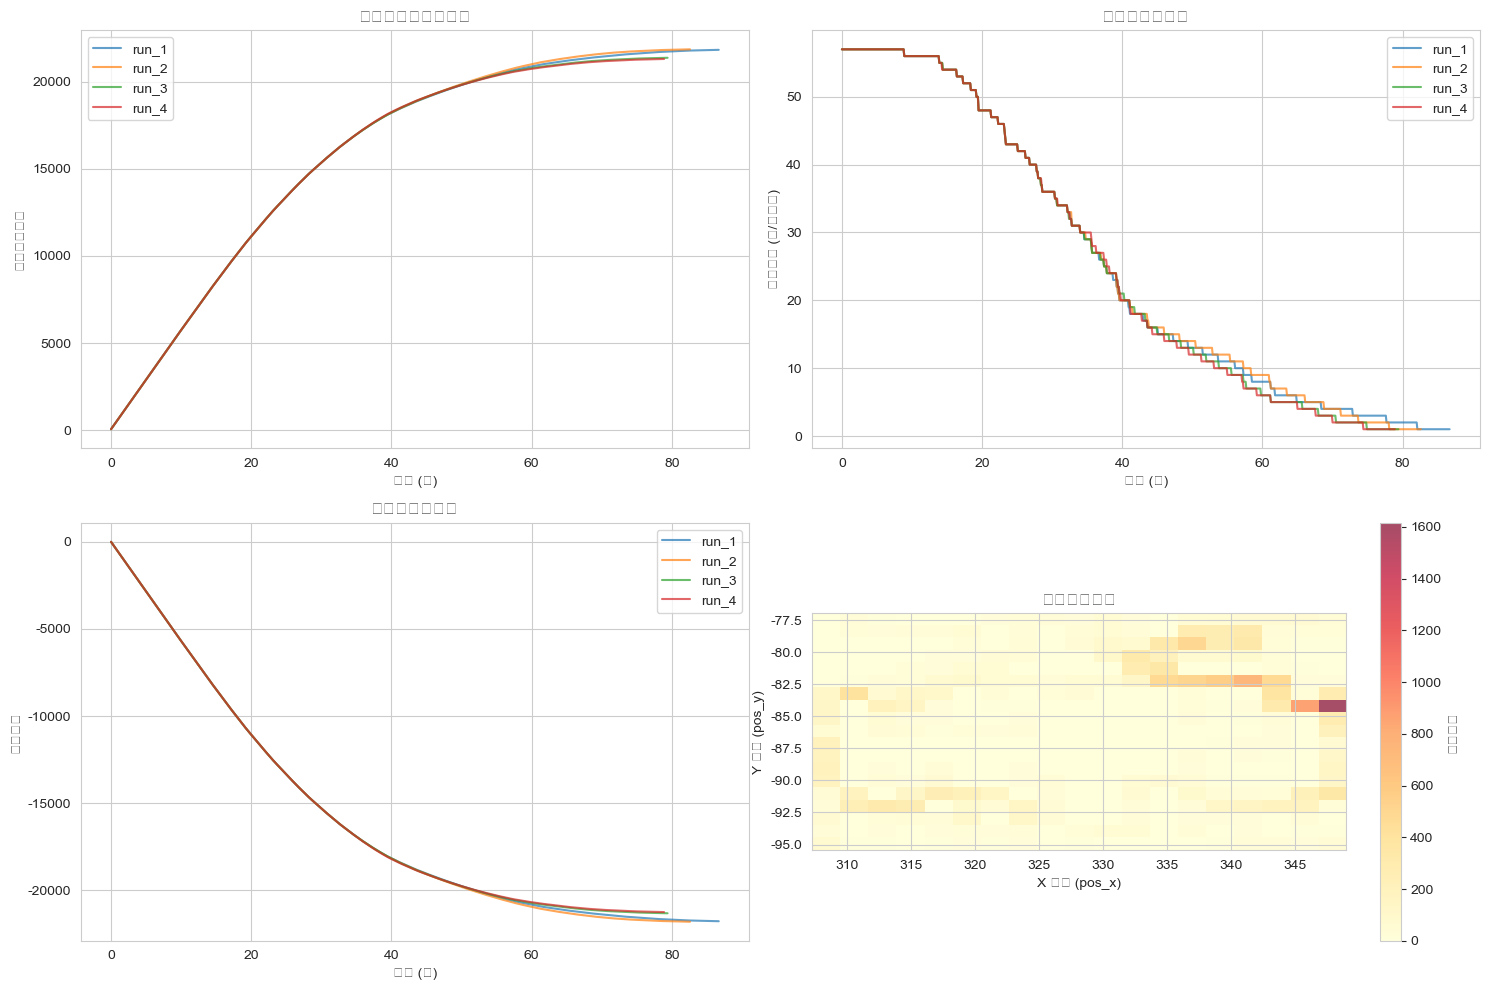

In [7]:
# 生成文字报告
analyzer.generate_report()

# 绘制时间线图表
analyzer.plot_evacuation_timeline()

# 绘制指标对比图                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    8ik9e2
#metrics_df, summary_stats = analyzer.plot_metrics_comparison()

# 导出Excel报告
#output_file = analyzer.export_results("my_evacuation_analysis.xlsx")
